In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

## Data Analysis Class

In [2]:
class dataClassifier:
    def __init__(self, X, y):
        self.precision = int(0)
        self.recall = int(0)
        self.f1_score = int(0)
        self.accuracy = int(0)
        self.matrix = ""
        self.global_y_test = ""
        self.global_y_pred = ""
        self.X = X
        self.y = y
        
    def dataAnalysis(self):
        
        # Create training and test split
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=0.30, random_state=1)
        
        self.global_y_test = y_test
        
        # Standardize the data set

        sc = StandardScaler()
        sc.fit(X_train)
        X_train_std = sc.transform(X_train)
        X_test_std = sc.transform(X_test)

        # Fit the SVC model

        svc = SVC(kernel='linear', C=10.0, random_state=1)
        svc.fit(X_train, y_train)

        # Get the predictions

        y_pred = svc.predict(X_test)
        
        self.global_y_pred = y_pred

        # Calculate the confusion matrix

        conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

        # Print the confusion matrix using Matplotlib

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.matshow(conf_matrix, cmap=plt.cm.Oranges, alpha=0.3)
        for i in range(conf_matrix.shape[0]):
            for j in range(conf_matrix.shape[1]):
                ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

        plt.xlabel('Predictions', fontsize=16)
        plt.ylabel('Actuals', fontsize=16)
        plt.title('Confusion Matrix', fontsize=16)
        self.matrix = plt
        self.scores()

    def scores(self):
        y_test = self.global_y_test
        y_pred = self.global_y_pred
        
        self.precision = (precision_score(y_test, y_pred) * 100)
        self.recall = (recall_score(y_test, y_pred) * 100)
        self.f1_score = (f1_score(y_test, y_pred) * 100)
        self.accuracy = (accuracy_score(y_test, y_pred) * 100)

## For Attribute Noise Results

In [3]:
an_cleaned = pd.read_csv('attribute_noise_cleaned.csv')
an_cleaned = an_cleaned.drop(['class_name', 'contents', 'max_noise'], axis=1)
X = an_cleaned.iloc[:, 0:1942]
y = an_cleaned.iloc[:, -1]

In [4]:
attributeNoiseObj = dataClassifier(X, y)

### Attribute Noise Result

Precision: 76.49
Recall: 92.37
F1 Score: 83.68
Accuracy: 71.98


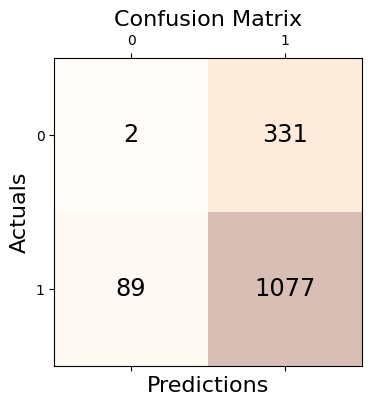

In [5]:
attributeNoiseObj.dataAnalysis()

print("Precision: %.2f" % attributeNoiseObj.precision)
print("Recall: %.2f" % attributeNoiseObj.recall)
print("F1 Score: %.2f" % attributeNoiseObj.f1_score)
print("Accuracy: %.2f" % attributeNoiseObj.accuracy)

## For Class Noise Results

In [6]:
cn_cleaned = pd.read_csv('class_noise_cleaned.csv')
cn_cleaned = cn_cleaned.drop(['class_name', 'contents', 'hashed_line'], axis=1)
X = cn_cleaned.iloc[:, 0:1942]
y = cn_cleaned.iloc[:, -1]

In [7]:
classNoiseObj = dataClassifier(X, y)

### Class Noise Result

Precision: 98.68
Recall: 97.03
F1 Score: 97.85
Accuracy: 96.93


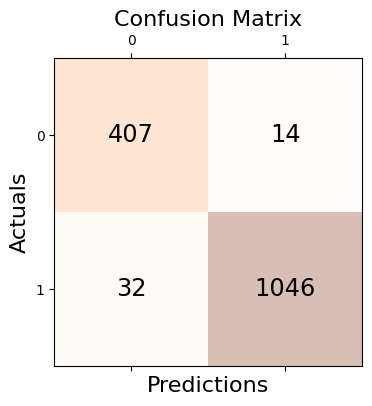

In [8]:
classNoiseObj.dataAnalysis()

print("Precision: %.2f" % classNoiseObj.precision)
print("Recall: %.2f" % classNoiseObj.recall)
print("F1 Score: %.2f" % classNoiseObj.f1_score)
print("Accuracy: %.2f" % classNoiseObj.accuracy)